# 03 · 訓練迴圈

上一課的網路只會亂猜。這堂課寫出**訓練迴圈**——深度學習的心跳。記住這四拍，你就能訓練任何 PyTorch 模型。

## 學習目標

- 背下訓練迴圈的四拍：**forward → loss → backward → step**
- 認識損失函數（`CrossEntropyLoss`）與優化器（`Adam`）
- 訓練上一課的網路，畫出 loss 曲線與學成的決策邊界

## 1. 訓練的四拍

```python
optimizer.zero_grad()      # 1. 清掉上一輪的梯度
loss = criterion(model(X), y)  # 2. forward + 算 loss
loss.backward()            # 3. 反向傳播，算每個參數的梯度
optimizer.step()           # 4. optimizer 沿梯度反方向更新參數
```

這四拍會跑很多輪（epoch），每輪都讓 loss 小一點。

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

torch.manual_seed(0)
X_np, y_np = make_moons(n_samples=300, noise=0.2, random_state=0)
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.long)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 16), nn.ReLU(),
            nn.Linear(16, 2),
        )
    def forward(self, x):
        return self.net(x)

model = MLP()
criterion = nn.CrossEntropyLoss()                      # 分類常用的損失
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

losses = []
for epoch in range(200):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"訓練後準確率：{(model(X).argmax(1) == y).float().mean():.1%}")

訓練後準確率：98.7%


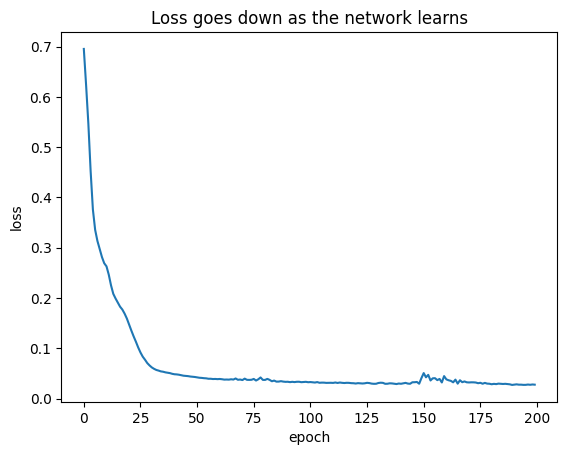

In [2]:
plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Loss goes down as the network learns")
plt.show()

## 2. 看它學到的決策邊界

訓練前是亂猜（~50%），訓練後應該逼近 100%。把決策邊界畫出來，看網路怎麼把兩個半月切開。

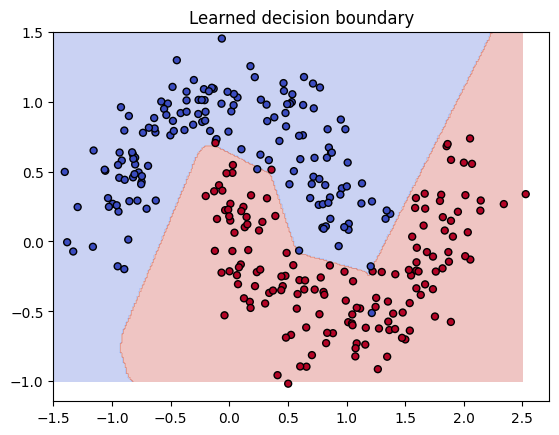

In [3]:
import numpy as np

xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 300), np.linspace(-1, 1.5, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = model(grid).argmax(1).numpy().reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap="coolwarm", edgecolor="k", s=25)
plt.title("Learned decision boundary"); plt.show()

那條彎曲的邊界，就是 ReLU 提供的非線性學出來的——一條直線永遠做不到。

## 小結

- 訓練迴圈四拍：`zero_grad` → `backward` → `step`，包夾著 forward + loss。
- `CrossEntropyLoss` 配分類、`Adam` 是好用的預設優化器。
- loss 曲線下降 = 網路在學；學完的決策邊界能彎曲貼合資料。
- 評估/畫圖時用 `torch.no_grad()`，省記憶體也更快。

## 練習

1. 把 `lr` 改成 0.001，要幾個 epoch 才追得上原本的準確率？
2. 把隱藏層寬度從 16 改成 4，邊界會變得多「鈍」？

下一課，進入**影像**——從全連接網路升級到 CNN，辨識手寫數字。